# Chapter 2 — Supervised Learning

## Learning Objectives

By the end of this notebook, you should be able to:

1. Explain the difference between **classification** and **regression**.
2. Describe **generalization**, **overfitting**, and **underfitting**.
3. Train and compare several supervised learning algorithms in `scikit-learn`.
4. Interpret model performance on training and test data.
5. Understand why preprocessing is important for some algorithms.

## Chapter Overview

Supervised learning is used when we have input data `X` and known target values `y`. The algorithm learns a mapping from input features to target output. If the output is categorical, the problem is classification. If the output is continuous, the problem is regression.

The most important goal is not merely to perform well on the training set, but to **generalize** well to new, unseen data. A model that memorizes the training set is overfitting. A model that is too simple to capture the pattern is underfitting.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Dataset Preparation

For classification, this notebook uses the **Breast Cancer Wisconsin dataset** from `scikit-learn`. The task is to predict whether a tumor is malignant or benign from numerical measurements.

This dataset is useful because it contains real-valued features, a binary target, and enough samples to compare multiple supervised learning algorithms.

### What this code does

- Loads the dataset.
- Separates features `X` and target `y`.
- Displays the shape, class names, and class distribution.

In [2]:
from sklearn.datasets import load_breast_cancer, load_diabetes

cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

print('Breast cancer data shape:', X.shape)
print('Target names:', cancer.target_names)
print('Class distribution:', np.bincount(y))

# Regression dataset for conceptual comparison
# The diabetes dataset has a continuous target value.
diabetes = load_diabetes()
print('\nDiabetes data shape:', diabetes.data.shape)
print('Diabetes target example:', diabetes.target[:5])

Breast cancer data shape: (569, 30)
Target names: ['malignant' 'benign']
Class distribution: [212 357]

Diabetes data shape: (442, 10)
Diabetes target example: [151.  75. 141. 206. 135.]


### Interpretation

The breast cancer dataset has samples represented by multiple numerical features. The target values are encoded as integers, but each integer corresponds to a class name. Since the target has discrete classes, this is a **classification problem**.

The diabetes dataset has a continuous target value, so it is an example of a **regression problem**.

## 2. Train-Test Split and Generalization

A model must be evaluated on data it has not seen during training. Therefore, we split the dataset into:

- **Training set:** used to fit the model.
- **Test set:** used to estimate generalization performance.

The `stratify=y` argument keeps the class ratio approximately the same in both sets. This is important for classification datasets, especially when classes are imbalanced.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=RANDOM_STATE
)

print('X_train shape:', X_train.shape)
print('X_test shape :', X_test.shape)
print('y_train distribution:', np.bincount(y_train))
print('y_test distribution :', np.bincount(y_test))

X_train shape: (426, 30)
X_test shape : (143, 30)
y_train distribution: [159 267]
y_test distribution : [53 90]


### Interpretation

The training set is larger than the test set because the model needs enough examples to learn useful patterns. The test set remains separate and is only used after training to estimate how the model performs on unseen data.

## 3. k-Nearest Neighbors Classifier

The k-Nearest Neighbors algorithm predicts a label by looking at the closest training samples.

### Important theory

- A small `k` creates a more complex model because predictions depend on very local patterns.
- A large `k` creates a smoother and simpler model.
- Too small `k` may overfit.
- Too large `k` may underfit.

### What this code does

The code trains several k-NN models using different values of `k`, then compares training accuracy and test accuracy.

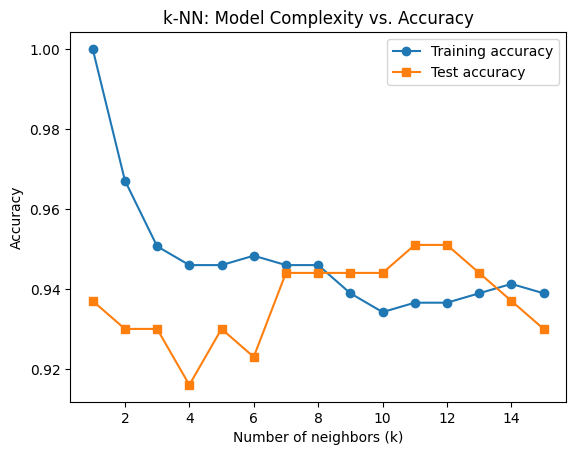

Best k based on test accuracy: 11
Best test accuracy: 0.951


In [4]:
from sklearn.neighbors import KNeighborsClassifier

train_scores = []
test_scores = []
k_values = range(1, 16)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_scores.append(knn.score(X_train, y_train))
    test_scores.append(knn.score(X_test, y_test))

plt.plot(k_values, train_scores, marker='o', label='Training accuracy')
plt.plot(k_values, test_scores, marker='s', label='Test accuracy')
plt.xlabel('Number of neighbors (k)')
plt.ylabel('Accuracy')
plt.title('k-NN: Model Complexity vs. Accuracy')
plt.legend()
plt.show()

best_k = list(k_values)[int(np.argmax(test_scores))]
print('Best k based on test accuracy:', best_k)
print('Best test accuracy:', round(max(test_scores), 4))

### Output Interpretation

If training accuracy is very high but test accuracy is lower, the model may be overfitting. If both training and test accuracy are low, the model may be underfitting. The best value of `k` is usually a middle point where the model is flexible enough to learn patterns but not too flexible to memorize noise.

## 4. Comparing Multiple Supervised Models

This section compares common supervised learning algorithms:

- **Logistic Regression:** linear classifier; strong baseline for many datasets.
- **Decision Tree:** interpretable rule-based model; can overfit if too deep.
- **Random Forest:** ensemble of decision trees; usually more robust than a single tree.
- **Gradient Boosting:** sequential ensemble that corrects previous mistakes.
- **SVM:** powerful classifier, but sensitive to feature scaling.
- **MLP Neural Network:** simple feed-forward neural network; also sensitive to scaling.

### Why pipelines are used

Some algorithms need feature scaling. A `Pipeline` ensures preprocessing is applied consistently to training and test data.

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=5000))
    ]),
    'Decision Tree': DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(C=10, gamma='scale'))
    ]),
    'MLP Neural Network': Pipeline([
        ('scaler', StandardScaler()),
        ('model', MLPClassifier(hidden_layer_sizes=(50,), alpha=1.0, max_iter=1000, random_state=RANDOM_STATE))
    ])
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    results.append((name, train_score, test_score))

results_df = pd.DataFrame(results, columns=['Model', 'Training Accuracy', 'Test Accuracy'])
print(results_df)

                 Model  Training Accuracy  Test Accuracy
0  Logistic Regression           0.988263       0.986014
1        Decision Tree           0.988263       0.944056
2        Random Forest           1.000000       0.958042
3    Gradient Boosting           1.000000       0.958042
4                  SVM           0.992958       0.979021
5   MLP Neural Network           0.985915       0.986014


### Output Interpretation

The comparison shows how different algorithms behave on the same dataset. A model with perfect or near-perfect training accuracy but lower test accuracy should be checked for overfitting. A strong model should perform well on the test set while maintaining a reasonable gap between training and test performance.

Tree-based ensembles often work well on tabular data. Linear models and SVMs can also perform strongly when features are properly scaled.

## 5. Feature Importance from Decision Tree

Decision trees and random forests can estimate feature importance. Feature importance indicates how much each feature contributes to reducing impurity in the tree.

### Important caution

Feature importance does not always prove causality. A feature can be important because it is correlated with the target or with another important feature.

worst radius            0.726829
worst concave points    0.122113
texture error           0.048398
worst texture           0.033231
worst concavity         0.018188
mean concave points     0.014158
area error              0.012613
mean texture            0.012585
worst symmetry          0.011885
mean area               0.000000
dtype: float64


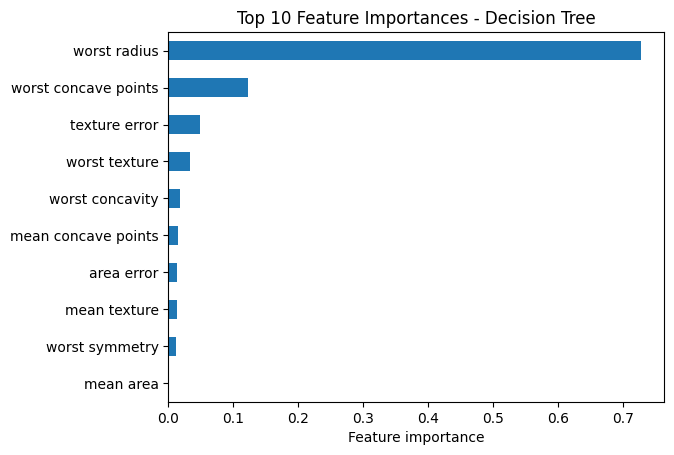

In [6]:
tree = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
tree.fit(X_train, y_train)

importance = pd.Series(tree.feature_importances_, index=cancer.feature_names).sort_values(ascending=False)
print(importance.head(10))

importance.head(10).sort_values().plot(kind='barh')
plt.xlabel('Feature importance')
plt.title('Top 10 Feature Importances - Decision Tree')
plt.show()

### Output Interpretation

The chart shows the features most frequently used by the decision tree to make splits. A high importance value means the feature helped the tree separate classes effectively. However, this should be interpreted carefully and ideally compared with domain knowledge.

## Key Takeaways

- Supervised learning learns from input-output pairs.
- Classification predicts categories; regression predicts continuous values.
- Generalization is the central goal of machine learning.
- Overfitting occurs when a model is too complex; underfitting occurs when it is too simple.
- Scaling is crucial for algorithms such as SVM, logistic regression, and neural networks.
- Ensemble methods such as Random Forest and Gradient Boosting are strong choices for tabular data.

## Chapter Summary

Chapter 2 introduces the practical foundation of supervised learning. It shows that model selection is not only about choosing the most advanced algorithm, but about understanding model complexity, data characteristics, preprocessing needs, and evaluation results.